In [1]:
!pip install tensorflow

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scipy 1.6.2 requires numpy<1.23.0,>=1.16.5, but you have numpy 1.24.3 which is incompatible.


  Attempting uninstall: zipp
    Found existing installation: zipp 3.4.1
    Uninstalling zipp-3.4.1:
      Successfully uninstalled zipp-3.4.1
  Attempting uninstall: importlib-metadata
    Found existing installation: importlib-metadata 3.10.0
    Uninstalling importlib-metadata-3.10.0:
      Successfully uninstalled importlib-metadata-3.10.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.20.1
    Uninstalling numpy-1.20.1:
      Successfully uninstalled numpy-1.20.1


In [1]:
pip list

Package                            Version
---------------------------------- -------------------
absl-py                            2.1.0
alabaster                          0.7.12
anaconda-client                    1.7.2
anaconda-navigator                 2.0.3
anaconda-project                   0.9.1
anyio                              2.2.0
appdirs                            1.4.4
argh                               0.26.2
argon2-cffi                        20.1.0
asn1crypto                         1.4.0
astroid                            2.5
astropy                            4.2.1
astunparse                         1.6.3
async-generator                    1.10
atomicwrites                       1.4.0
attrs                              20.3.0
autopep8                           1.5.6
Babel                              2.9.0
backcall                           0.2.0
backports.functools-lru-cache      1.6.4
backports.shutil-get-terminal-size 1.0.0
backports.tempfile                 1.0
b

In [2]:
pip install "numpy>=1.16.5,<1.23.0"

  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:
      Successfully uninstalled numpy-1.24.3
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip list

Package                            Version
---------------------------------- -------------------
absl-py                            2.1.0
alabaster                          0.7.12
anaconda-client                    1.7.2
anaconda-navigator                 2.0.3
anaconda-project                   0.9.1
anyio                              2.2.0
appdirs                            1.4.4
argh                               0.26.2
argon2-cffi                        20.1.0
asn1crypto                         1.4.0
astroid                            2.5
astropy                            4.2.1
astunparse                         1.6.3
async-generator                    1.10
atomicwrites                       1.4.0
attrs                              20.3.0
autopep8                           1.5.6
Babel                              2.9.0
backcall                           0.2.0
backports.functools-lru-cache      1.6.4
backports.shutil-get-terminal-size 1.0.0
backports.tempfile                 1.0
b

In [ ]:
!pip uninstall tensorflow

# Keras Syntax Basics

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
df = pd.read_csv('/Users/divya/Udemy_NumpyPandaBootscamp_sampleFiles/TensorFlow_FILES/DATA/fake_reg.csv')

In [11]:
df.head()

,price,feature1,feature2
0,461.527929,999.787558,999.766096
1,548.130011,998.861615,1001.042403
2,410.297162,1000.070267,998.844015
3,540.382220,999.952251,1000.440940
4,546.024553,1000.446011,1000.338531


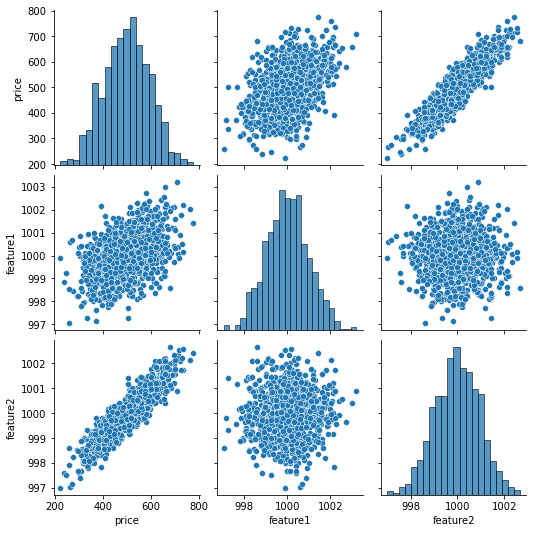

In [12]:
sns.pairplot(df)

In [9]:
#using keras and tf

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
#just to convert our detaset to numpy array
X = df[['feature1', 'feature2']].values

In [15]:
y = df['price'].values

In [16]:
X

array([[ 999.78755752,  999.7660962 ],
       [ 998.86161491, 1001.04240315],
       [1000.07026691,  998.84401463],
       ...,
       [1001.45164617,  998.84760554],
       [1000.77102275,  998.56285086],
       [ 999.2322436 , 1001.45140713]])

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [40]:
X_train.shape

(700, 2)

In [19]:
X_test.shape

(300, 2)

In [20]:
from sklearn.preprocessing import MinMaxScaler

In [26]:
help(MinMaxScaler)

Help on class MinMaxScaler in module sklearn.preprocessing._data:

class MinMaxScaler(sklearn.base.TransformerMixin, sklearn.base.BaseEstimator)
 |  MinMaxScaler(feature_range=(0, 1), *, copy=True, clip=False)
 |  
 |  Transform features by scaling each feature to a given range.
 |  
 |  This estimator scales and translates each feature individually such
 |  that it is in the given range on the training set, e.g. between
 |  zero and one.
 |  
 |  The transformation is given by::
 |  
 |      X_std = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
 |      X_scaled = X_std * (max - min) + min
 |  
 |  where min, max = feature_range.
 |  
 |  This transformation is often used as an alternative to zero mean,
 |  unit variance scaling.
 |  
 |  Read more in the :ref:`User Guide <preprocessing_scaler>`.
 |  
 |  Parameters
 |  ----------
 |  feature_range : tuple (min, max), default=(0, 1)
 |      Desired range of transformed data.
 |  
 |  copy : bool, default=True
 |      Set to Fal

In [41]:
scaler = MinMaxScaler()#we dont need to scale the label

In [42]:
scaler.fit(X_train)#we do only on training set as we want to control the data leakage

MinMaxScaler()

In [43]:
X_train = scaler.transform(X_train)

In [24]:
X_test = scaler.transform(X_test)

In [45]:
X_train.shape

(700, 2)

In [27]:
#creating model, running model and creating prediction using model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [28]:
help(Sequential)

Help on class Sequential in module keras.src.engine.sequential:

class Sequential(keras.src.engine.functional.Functional)
 |  Sequential(*args, **kwargs)
 |  
 |  `Sequential` groups a linear stack of layers into a `tf.keras.Model`.
 |  
 |  `Sequential` provides training and inference features on this model.
 |  
 |  Examples:
 |  
 |  ```python
 |  # Optionally, the first layer can receive an `input_shape` argument:
 |  model = tf.keras.Sequential()
 |  model.add(tf.keras.layers.Dense(8, input_shape=(16,)))
 |  # Afterwards, we do automatic shape inference:
 |  model.add(tf.keras.layers.Dense(4))
 |  
 |  # This is identical to the following:
 |  model = tf.keras.Sequential()
 |  model.add(tf.keras.Input(shape=(16,)))
 |  model.add(tf.keras.layers.Dense(8))
 |  
 |  # Note that you can also omit the `input_shape` argument.
 |  # In that case the model doesn't have any weights until the first call
 |  # to a training/evaluation method (since it isn't yet built):
 |  model = tf.keras.S

In [29]:
help(Dense)

Help on class Dense in module keras.src.layers.core.dense:

class Dense(keras.src.engine.base_layer.Layer)
 |  Dense(*args, **kwargs)
 |  
 |  Just your regular densely-connected NN layer.
 |  
 |  `Dense` implements the operation:
 |  `output = activation(dot(input, kernel) + bias)`
 |  where `activation` is the element-wise activation function
 |  passed as the `activation` argument, `kernel` is a weights matrix
 |  created by the layer, and `bias` is a bias vector created by the layer
 |  (only applicable if `use_bias` is `True`). These are all attributes of
 |  `Dense`.
 |  
 |  Note: If the input to the layer has a rank greater than 2, then `Dense`
 |  computes the dot product between the `inputs` and the `kernel` along the
 |  last axis of the `inputs` and axis 0 of the `kernel` (using `tf.tensordot`).
 |  For example, if input has dimensions `(batch_size, d0, d1)`, then we create
 |  a `kernel` with shape `(d1, units)`, and the `kernel` operates along axis 2
 |  of the `input`, 

#creating keras space model
model = Sequential([Dense(4, activation='relu'),
                   Dense(2, activation='relu'),
                   Dense(1)])

In [ ]:
#convenient manner below - use this regularly

In [56]:
model = Sequential()

In [57]:
model.add(Dense(4, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(4, activation='relu'))

model.add(Dense(1))

In [58]:
model.compile(optimizer='rmsprop', loss='mse')

In [59]:
model.fit(x= X_train, y= y_train, epochs= 250)

Epoch 1/250
22/22 [==============================] - 0s 1ms/step - loss: 256609.0781
Epoch 2/250
22/22 [==============================] - 0s 1ms/step - loss: 256433.3906
Epoch 3/250
22/22 [==============================] - 0s 1ms/step - loss: 256249.3281
Epoch 4/250
22/22 [==============================] - 0s 1ms/step - loss: 256035.6875
Epoch 5/250
22/22 [==============================] - 0s 1ms/step - loss: 255783.4219
Epoch 6/250
22/22 [==============================] - 0s 1ms/step - loss: 255484.5000
Epoch 7/250
22/22 [==============================] - 0s 1ms/step - loss: 255133.2500
Epoch 8/250
22/22 [==============================] - 0s 1ms/step - loss: 254722.3125
Epoch 9/250
22/22 [==============================] - 0s 1ms/step - loss: 254254.2344
Epoch 10/250
22/22 [==============================] - 0s 1ms/step - loss: 253725.2188
Epoch 11/250
22/22 [==============================] - 0s 1ms/step - loss: 253136.5000
Epoch 12/250
22/22 [==============================] - 0s 1ms/st

In [60]:
loss_df = pd.DataFrame(model.history.history)

<AxesSubplot:>

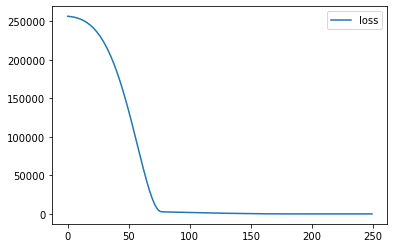

In [61]:
loss_df.plot()

# Part 3


In [62]:
#evaluation of model
model.evaluate(x= X_train, y= y_train, verbose=0)

24.671430587768555

In [63]:
model.evaluate(x= X_test, y= y_test, verbose=0)

26.947021484375

In [64]:
predictions = model.predict(X_test)

10/10 [==============================] - 0s 1ms/step


In [65]:
predictions

array([[406.31467],
       [625.15125],
       [593.6728 ],
       [573.66846],
       [367.4773 ],
       [580.6628 ],
       [516.31415],
       [460.30103],
       [550.6267 ],
       [448.68683],
       [613.36743],
       [550.4166 ],
       [420.15747],
       [409.89038],
       [652.99084],
       [438.42737],
       [509.80453],
       [661.5897 ],
       [664.27826],
       [567.01746],
       [335.0307 ],
       [445.96155],
       [383.46753],
       [379.7115 ],
       [568.0497 ],
       [612.1378 ],
       [533.7487 ],
       [428.95175],
       [657.1063 ],
       [415.15393],
       [443.78497],
       [486.368  ],
       [439.53314],
       [683.5897 ],
       [425.87476],
       [418.71924],
       [503.27686],
       [551.89594],
       [510.99313],
       [396.29846],
       [620.20325],
       [417.70166],
       [606.0212 ],
       [447.13727],
       [503.27322],
       [583.28107],
       [670.7838 ],
       [491.68045],
       [319.39844],
       [486.66235],


In [89]:
test_predictions = pd.Series(predictions.reshape(300,))

In [90]:
test_predictions

0      406.314667
1      625.151245
2      593.672791
3      573.668457
4      367.477295
          ...    
295    530.375793
296    516.553894
297    611.232788
298    418.039673
299    411.892731
Length: 300, dtype: float32

In [91]:
pred_df = pd.DataFrame(y_test, columns=['Test True Y'])

In [92]:
pred_df

,Test True Y
0,402.296319
1,624.156198
2,582.455066
3,578.588606
4,371.224104
...,...
295,525.704657
296,502.909473
297,612.727910
298,417.569725


In [93]:
pred_df = pd.concat([pred_df, test_predictions], axis=1)
pred_df

,Test True Y,0
0,402.296319,406.314667
1,624.156198,625.151245
2,582.455066,593.672791
3,578.588606,573.668457
4,371.224104,367.477295
...,...,...
295,525.704657,530.375793
296,502.909473,516.553894
297,612.727910,611.232788
298,417.569725,418.039673


In [95]:
pred_df.columns = ['Test True Y', 'Model Predictions']

In [96]:
pred_df

,Test True Y,Model Predictions
0,402.296319,406.314667
1,624.156198,625.151245
2,582.455066,593.672791
3,578.588606,573.668457
4,371.224104,367.477295
...,...,...
295,525.704657,530.375793
296,502.909473,516.553894
297,612.727910,611.232788
298,417.569725,418.039673


<AxesSubplot:xlabel='Test True Y', ylabel='Model Predictions'>

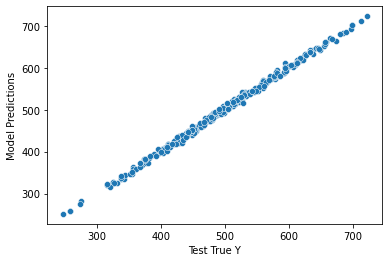

In [100]:
sns.scatterplot(x = 'Test True Y', y='Model Predictions', data=pred_df)

In [101]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [102]:
mean_absolute_error(pred_df['Test True Y'], pred_df['Model Predictions'])

4.2099735239608345

In [103]:
mean_squared_error(pred_df['Test True Y'], pred_df['Model Predictions'])

26.947021706122868

In [104]:
df.describe()

,price,feature1,feature2
count,1000.000000,1000.000000,1000.000000
mean,498.673029,1000.014171,999.979847
std,93.785431,0.974018,0.948330
min,223.346793,997.058347,996.995651
25%,433.025732,999.332068,999.316106
50%,502.382117,1000.009915,1000.002243
75%,564.921588,1000.637580,1000.645380
max,774.407854,1003.207934,1002.666308


In [124]:
np.sqrt(mean_squared_error(pred_df['Test True Y'], pred_df['Model Predictions']))

5.19105208085248

In [125]:
new_gem = [[998,999]]

In [126]:
new_gem = scaler.transform(new_gem)
new_gem

array([[998., 999.]])

In [127]:
model.predict(new_gem)

1/1 [==============================] - 0s 19ms/step


array([[736745.2]], dtype=float32)

In [119]:
from tensorflow.keras.models import load_model

In [128]:
model.save('my_gem_model.h5')

C:\Users\divya\anaconda3\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [129]:
later_model = load_model('my_gem_model.h5')

In [130]:
later_model.predict(new_gem)

1/1 [==============================] - 0s 61ms/step


array([[736745.2]], dtype=float32)

In [131]:
later_model.predict([[997,996]])

1/1 [==============================] - 0s 70ms/step


array([[735018.94]], dtype=float32)